# Master Results Notebook for Paper Production

This notebook serves as the primary driver for generating the final, publication-quality figures and tables for the paper. It leverages the consolidated logic in `src/glass/` to ensure zero data loss and reproducible results.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

We start by loading the necessary filters (UVJ, ugr, IRAC) and the base Type 1 and Type 2 AGN SKIRTOR models using parameters defined in the project's modelling methodology.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate Colours

We will iterate over the alpha values, calculate composite SEDs for all templates and both AGN types, and compute their colours. For `ugr` and `IRAC` diagrams, specific artificial redshifting is applied to reflect survey selections.

In [3]:
results = []
alphas = config.ALPHA_VALUES

# Target redshifts for artificial redshifting
z_ugr = 3.0 # Within the U-dropout target range of 2.6 < z < 3.6
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}")
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            
            # Calculate UVJ (restframe)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            # Calculate ugr (redshifted to z=3.0)
            ug, gr = photometry.calculate_ugr_colours(comp_sed, filters['u'], filters['g'], filters['r'], redshift=z_ugr)
            
            # Calculate IRAC (restframe)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj,
                'u-g': ug,
                'g-r': gr,
                'f5836': f5836,
                'f8045': f8045
            })

df_results = pd.DataFrame(results)
print("Processed all composite combinations.")

Processing template 1/128: Arp_118
Processing template 2/128: Arp_256_N
Processing template 3/128: Arp_256_S
Processing template 4/128: CGCG_049-057
Processing template 5/128: CGCG_436-030
Processing template 6/128: CGCG_453-062


Processing template 7/128: Haro_06
Processing template 8/128: IC_0691
Processing template 9/128: IC_0860
Processing template 10/128: IC_0883
Processing template 11/128: IC_4051
Processing template 12/128: IC_4553


Processing template 13/128: IC_5298
Processing template 14/128: III_Zw_035
Processing template 15/128: II_Zw_096
Processing template 16/128: IRAS_08572+3915
Processing template 17/128: IRAS_17208-0014


Processing template 18/128: Mrk_0331
Processing template 19/128: Mrk_0475
Processing template 20/128: Mrk_0930
Processing template 21/128: Mrk_1450
Processing template 22/128: Mrk_1490
Processing template 23/128: Mrk_33


Processing template 24/128: NGC_0337
Processing template 25/128: NGC_0474
Processing template 26/128: NGC_0520
Processing template 27/128: NGC_0584
Processing template 28/128: NGC_0628
Processing template 29/128: NGC_0660


...

Processing template 108/128: NGC_7673
Processing template 109/128: NGC_7674
Processing template 110/128: NGC_7679
Processing template 111/128: NGC_7714
Processing template 112/128: NGC_7771
Processing template 113/128: UGCA_166


Processing template 114/128: UGCA_208
Processing template 115/128: UGCA_219
Processing template 116/128: UGCA_410
Processing template 117/128: UGC_04881
Processing template 118/128: UGC_05101


Processing template 119/128: UGC_06665
Processing template 120/128: UGC_06850
Processing template 121/128: UGC_08335_NW
Processing template 122/128: UGC_08335_SE
Processing template 123/128: UGC_08696


Processing template 124/128: UGC_09618_N
Processing template 125/128: UGC_09618
Processing template 126/128: UGC_09618_S
Processing template 127/128: UGC_12150
Processing template 128/128: UM_461


Processed all composite combinations.


## 3. Colour Evolution Evolution Plots

These plots show how individual galaxies move through colour-colour space as the AGN contribution ($\alpha$) increases from 0 to 1.

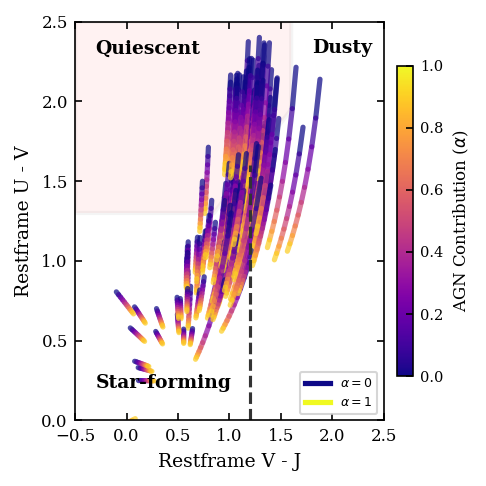

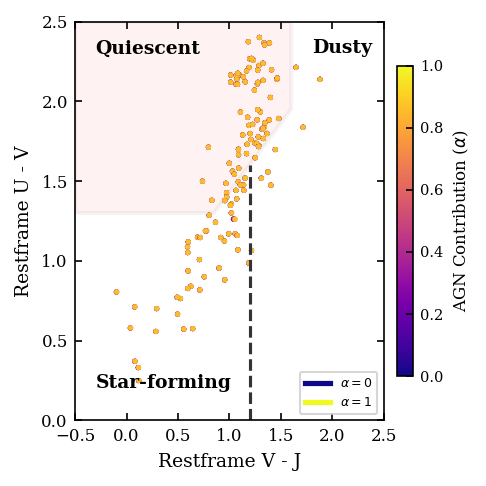

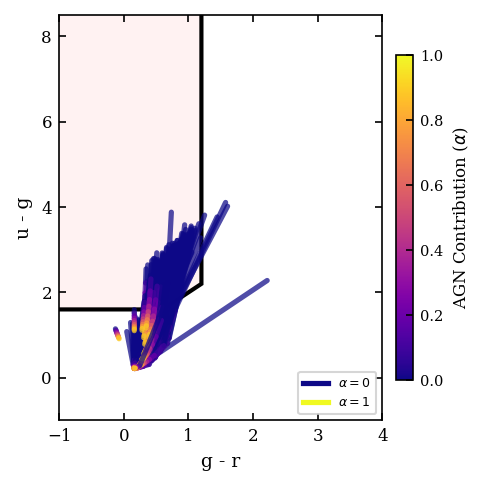

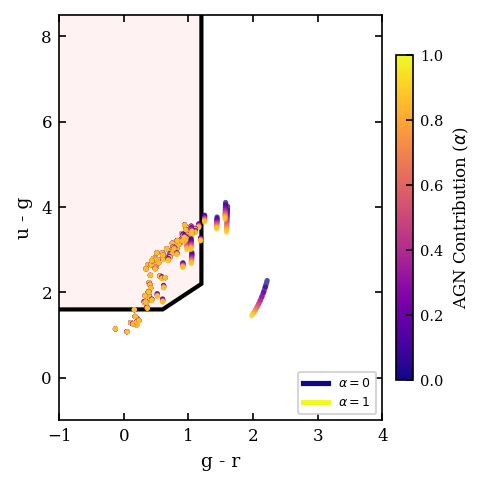

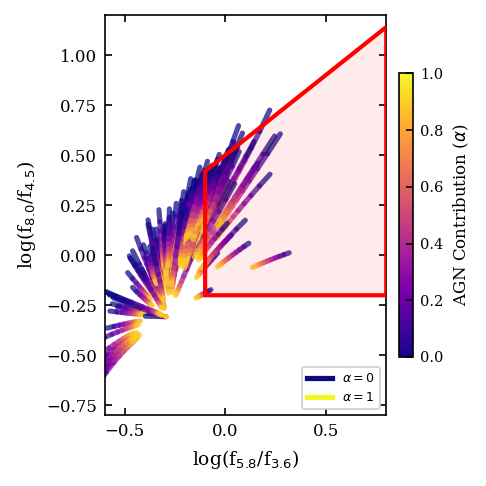

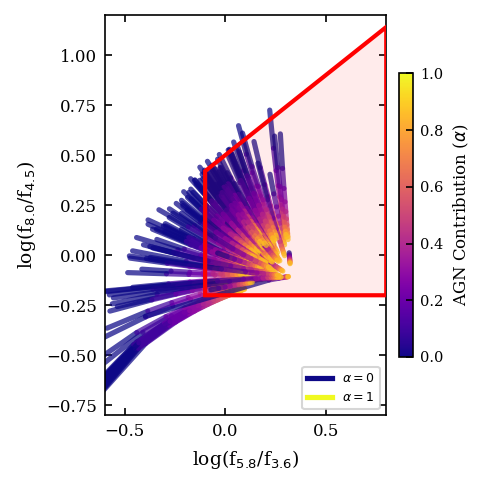

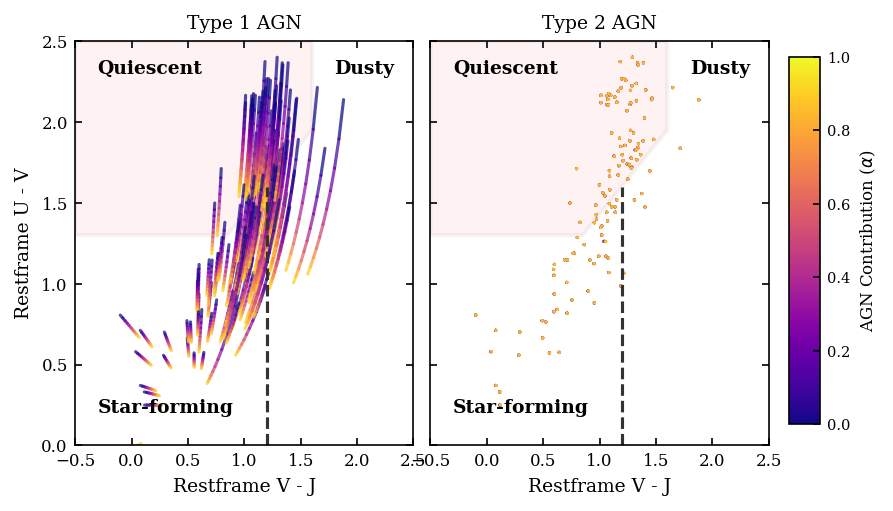

In [4]:
def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, title, output_name):
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    subset = df[df['AGN_Type'] == agn_type]

    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=0, vmax=1)

    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs = temp_df[x_col].values
        ys = temp_df[y_col].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2],
                    color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=2.5, alpha=0.72, solid_capstyle='round')

    plot_func([], [], ax=ax, title=title)

    custom_lines = [
        Line2D([0], [0], color=cmap(0.0), lw=2.5, label=r'$\alpha=0$'),
        Line2D([0], [0], color=cmap(1.0), lw=2.5, label=r'$\alpha=1$'),
    ]
    ax.legend(handles=custom_lines, loc='lower right', fontsize=6)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, output_name), dpi=300, bbox_inches='tight')
    return fig, ax

plot_evolution_tracks(df_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram,
                      '', 'Paper_UVJ_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram,
                      '', 'Paper_UVJ_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type2.pdf')

# --- Combined UVJ evolution: Type 1 left, Type 2 right, shared y-axis ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_results[df_results['AGN_Type'] == agn_type]
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs, ys = temp_df['V-J'].values, temp_df['U-V'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=1.5, alpha=0.72, solid_capstyle='round')
    panel_title = 'Type 1 AGN' if agn_type == 'Type1' else 'Type 2 AGN'
    visualization.plot_uvj_diagram([], [], ax=ax, title=panel_title)

ax2.set_ylabel('')

fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Evolution_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 3b. SWIRE Template Evolution (Fig 3)

Generating initial composite modelling using the SWIRE template library.

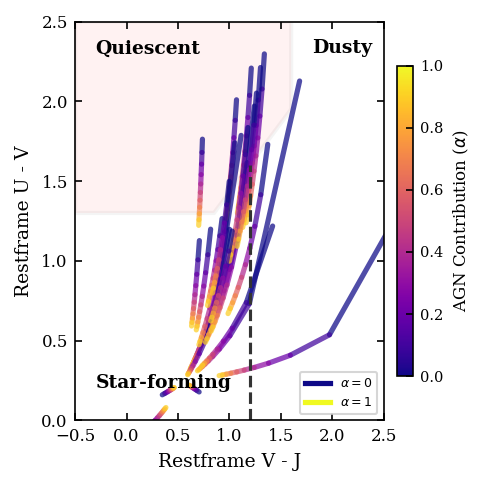

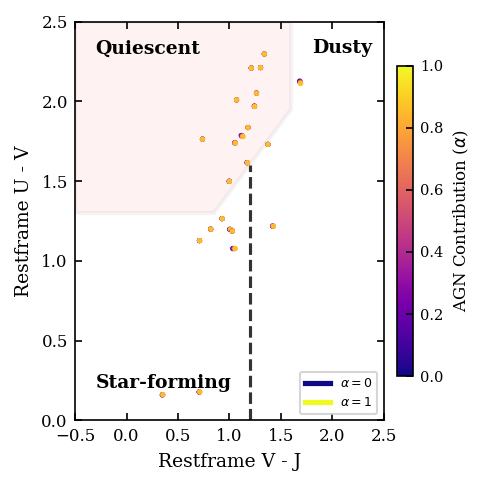

In [5]:
# Load SWIRE Templates
swire_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'SWIRE')
swire_templates, swire_names = data_io.read_swire_templates(swire_dir)

swire_results = []

for t_idx, gal_sed in enumerate(swire_templates):
    gal_name = swire_names[t_idx]
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            swire_results.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})

df_swire_results = pd.DataFrame(swire_results)

plot_evolution_tracks(df_swire_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, '', 'SWIREType1AGNUVJ.pdf')
plot_evolution_tracks(df_swire_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, '', 'SWIREType2AGNUVJ.pdf')
plt.show()

## 4. Selection Completeness Analysis

Evaluating how well the standard selection wedges (UVJ, ugr dropout, Lacy IRAC) identify their targets as AGN contamination increases.

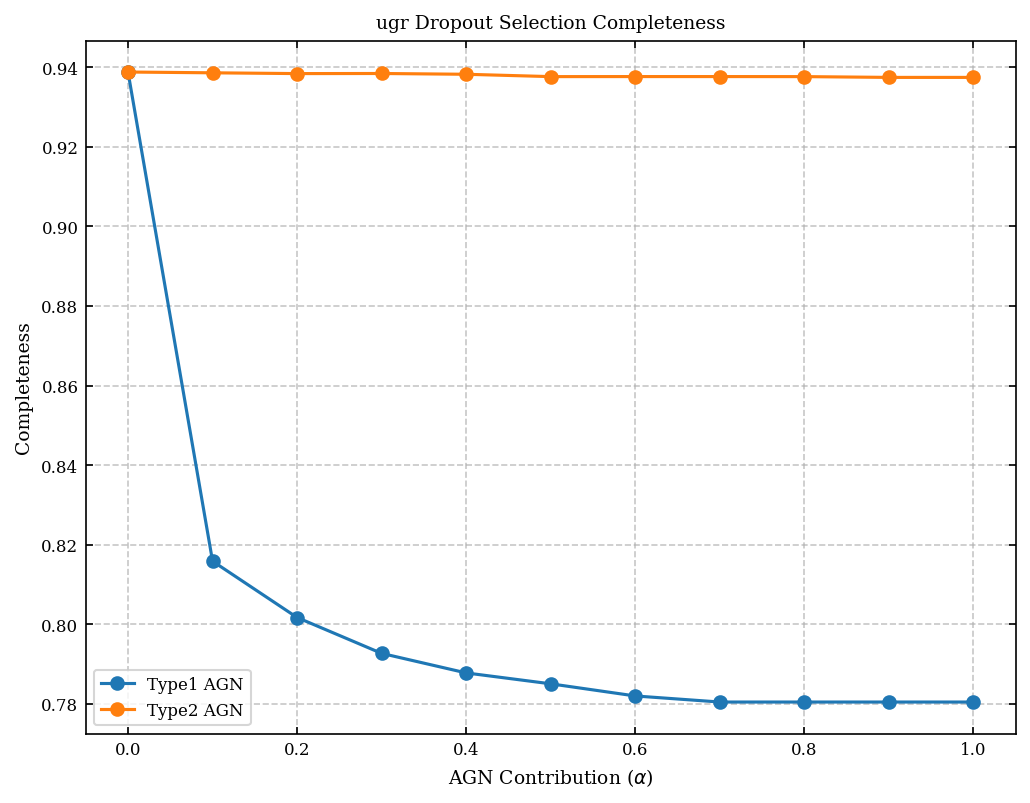

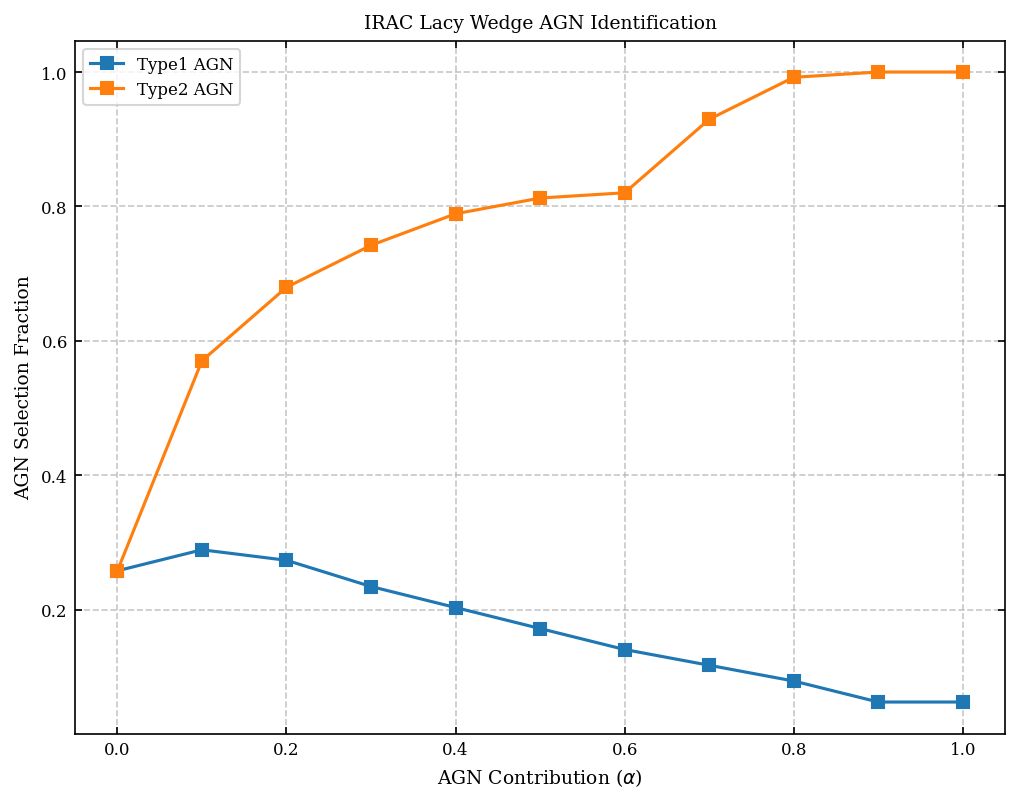

In [6]:
# 1. ugr Dropout Completeness (from redshift grid data)
grid_file = os.path.join(config.PROCESSED_DATA_DIR, 'ugr_completeness_grid.csv')
if os.path.exists(grid_file):
    df_grid = pd.read_csv(grid_file)
    df_comp_ugr = analysis.calculate_completeness_from_df(df_grid)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for agn_type in df_comp_ugr['AGN_Type'].unique():
        subset = df_comp_ugr[df_comp_ugr['AGN_Type'] == agn_type]
        ax.plot(subset['Alpha'], subset['Completeness'], marker='o', label=f'{agn_type} AGN')
        
    ax.set_xlabel(r'AGN Contribution ($\alpha$)')
    ax.set_ylabel('Completeness')
    ax.set_title('ugr Dropout Selection Completeness')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_ugr_Completeness.pdf'), bbox_inches='tight')
    plt.show()

# 2. IRAC Lacy Wedge Completeness (calculated from df_results)
def calculate_irac_completeness(df):
    res = []
    for agn_type in df['AGN_Type'].unique():
        subset = df[df['AGN_Type'] == agn_type]
        for alpha in subset['Alpha'].unique():
            alpha_df = subset[subset['Alpha'] == alpha]
            in_wedge = analysis.is_in_lacy_wedge(alpha_df['f5836'], alpha_df['f8045'])
            # For IRAC, completeness is fraction identified as AGN
            completeness = np.sum(in_wedge) / len(alpha_df)
            res.append({'AGN_Type': agn_type, 'Alpha': alpha, 'Completeness': completeness})
    return pd.DataFrame(res)

df_comp_irac = calculate_irac_completeness(df_results)

fig, ax = plt.subplots(figsize=(8, 6))
for agn_type in df_comp_irac['AGN_Type'].unique():
    subset = df_comp_irac[df_comp_irac['AGN_Type'] == agn_type]
    ax.plot(subset['Alpha'], subset['Completeness'], marker='s', label=f'{agn_type} AGN')
    
ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('AGN Selection Fraction')
ax.set_title('IRAC Lacy Wedge AGN Identification')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Completeness.pdf'), bbox_inches='tight')
plt.show()

## 5. Statistical Tables (LaTeX Exports)

Exporting the final results to LaTeX for inclusion in the paper.

In [7]:
def calculate_uvj_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        vj_alpha = alpha_df['V-J'].values
        uv_alpha = alpha_df['U-V'].values
        vj_init = initial_df['V-J'].values
        uv_init = initial_df['U-V'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(vj_alpha, uv_alpha, vj_init, uv_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_uvj_offsets(df_results, 'Type1')
off2 = calculate_uvj_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution ($\\alpha$)': [f"{int(a*100)}\\%" for a in alphas],
    'Type 1 Offset (dex)': off1['Mean_Offset'].round(3),
    'Type 2 Offset (dex)': off2['Mean_Offset'].round(3)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset for Type 1 and Type 2 AGN composites in the UVJ diagram.", label="tab:UVJ_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported UVJ Vector Offset table.")

,AGN Contribution ($\\alpha$),Type 1 Offset (dex),Type 2 Offset (dex)
0,0\%,0.000,0.000
1,10\%,0.090,0.000
2,20\%,0.165,0.000
3,30\%,0.229,0.001
4,40\%,0.285,0.001
5,50\%,0.335,0.001
6,60\%,0.380,0.001
7,70\%,0.420,0.002
8,80\%,0.457,0.002
9,90\%,0.491,0.002


Exported UVJ Vector Offset table.


## 6. UVJ Population Fraction Analysis

This section analyzes how AGN contamination causes galaxies to migrate between the Star-forming, Quiescent, and Dusty regions of the UVJ diagram.

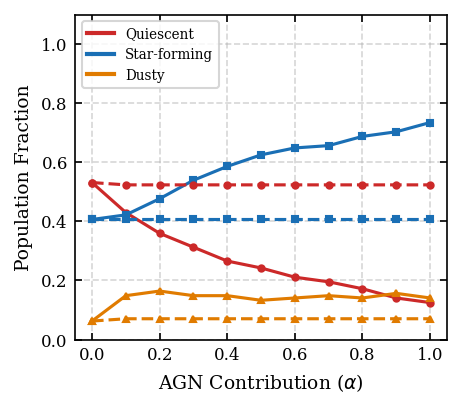

In [8]:
def calculate_uvj_fractions(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    alphas_sorted = sorted(subset['Alpha'].unique())
    q_fracs, sf_fracs, d_fracs = [], [], []
    for alpha in alphas_sorted:
        alpha_df = subset[subset['Alpha'] == alpha]
        classifications = analysis.classify_uvj(alpha_df['V-J'], alpha_df['U-V'])
        q, sf, d = analysis.calculate_population_fractions(classifications)
        q_fracs.append(q)
        sf_fracs.append(sf)
        d_fracs.append(d)
    return alphas_sorted, q_fracs, sf_fracs, d_fracs

fig, ax = plt.subplots(figsize=(3.15, 2.8))

pop_colors = {'Quiescent': '#CC2929', 'Star-forming': '#1A6FB5', 'Dusty': '#E07B00'}

for agn_type, ls in [('Type1', '-'), ('Type2', '--')]:
    alphas_sorted, q_fracs, sf_fracs, d_fracs = calculate_uvj_fractions(df_results, agn_type)
    type_label = 'Type 1' if agn_type == 'Type1' else 'Type 2'
    ax.plot(alphas_sorted, q_fracs,  color=pop_colors['Quiescent'],    linestyle=ls, marker='o', markersize=3, label=f'Quiescent ({type_label})')
    ax.plot(alphas_sorted, sf_fracs, color=pop_colors['Star-forming'], linestyle=ls, marker='s', markersize=3, label=f'Star-forming ({type_label})')
    ax.plot(alphas_sorted, d_fracs,  color=pop_colors['Dusty'],        linestyle=ls, marker='^', markersize=3, label=f'Dusty ({type_label})')

ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('Population Fraction')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim([0, 1.1])

# Compact legend: colour = population. Solid = Type 1, dashed = Type 2
# (line style distinction is explained in the figure caption, not the legend).
color_handles = [
    Line2D([0],[0], color=pop_colors['Quiescent'],    lw=2, label='Quiescent'),
    Line2D([0],[0], color=pop_colors['Star-forming'], lw=2, label='Star-forming'),
    Line2D([0],[0], color=pop_colors['Dusty'],        lw=2, label='Dusty'),
]
ax.legend(handles=color_handles, fontsize=6.5, loc='upper left')

plt.tight_layout()
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Fractions_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Composite SED Progression (Fig 6)

Recreating Figure 6: 1D SED progression for representative Star-forming, Quiescent, and Dusty galaxies with increasing Type 1 AGN contribution.

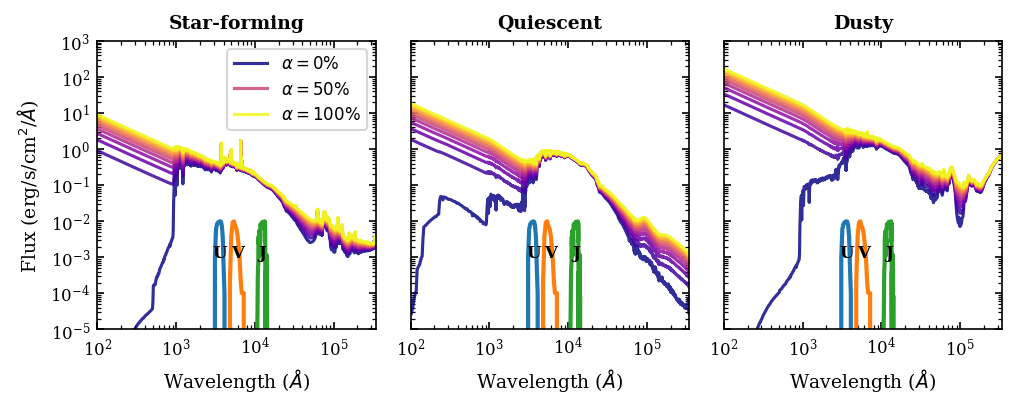

In [9]:
# Representative templates from Brown (GALSEDATLAS) set
# Star-forming: NGC_0337, Quiescent: NGC_4552, Dusty: IC_4553 (Arp 220)
rep_templates = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553'
}

comp_progression_data = {}

for pop_name, gal_name in rep_templates.items():
    if gal_name in brown_names:
        t_idx = brown_names.index(gal_name)
        gal_sed = brown_templates[t_idx]
        comp_progression_data[pop_name] = {}
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_type1, gal_sed, alpha)
            comp_progression_data[pop_name][alpha] = comp_sed

visualization.plot_composite_sed_progression(
    comp_progression_data, filters,
    show_title=True,
    orientation='horizontal',
    figsize=visualization.PASA_SED_WIDE,
    output_path=os.path.join(config.PROCESSED_DATA_DIR, 'CompositeSEDs_UVJ.pdf')
)
plt.show()

## 8. Observational ZFOURGE Composites (Fig 7, 8, Table 4)

This section confirms theoretical trends using observational ZFOURGE data by tracking how the average galaxy in each UVJ region evolves with increasing Type 1 AGN contribution.

C:\Users\uqmhooym\AppData\Local\Temp\ipykernel_25276\3976255729.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])


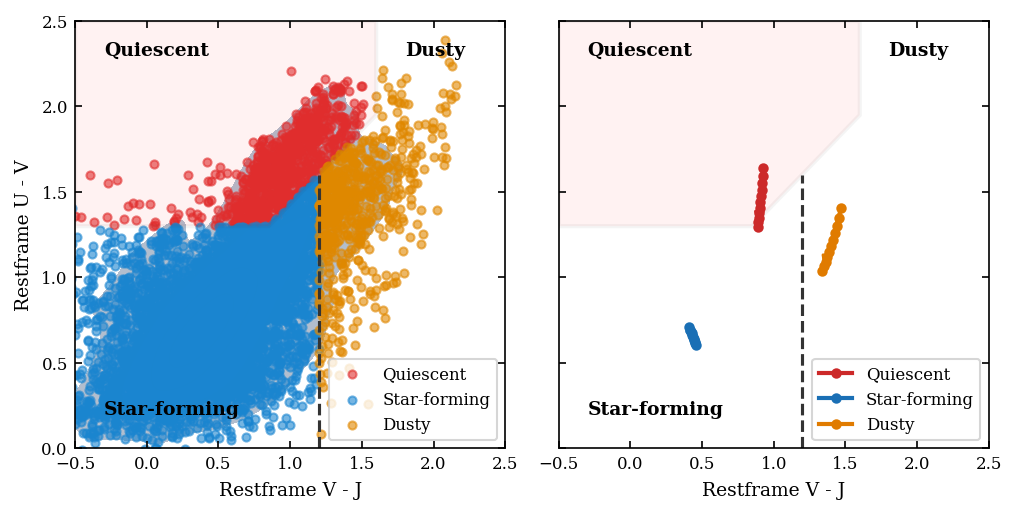

In [10]:
# Load the pre-generated observational composite data (calculated during Honours phase)
obs_csv_path = os.path.join('..\outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')
if os.path.exists(obs_csv_path):
    df_obs = pd.read_csv(obs_csv_path, index_col=0)

    # Re-classify Alpha=0 galaxies
    df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])

    # Fig 7: UVJ Density at Alpha=0% (left, initial state) + Average Region Tracks (right), combined double plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharey=True)

    # Left panel: initial state (Alpha=0%)
    uv_0 = df_obs['U_0'] - df_obs['V_0']
    vj_0 = df_obs['V_0'] - df_obs['J_0']
    visualization.plot_uvj_diagram(vj_0, uv_0, classifications=df_obs['Classification'],
                                   show_density=True, ax=ax1, title="",
                                   scatter_colors=('#E03030', '#1A85D0', '#E08800'))

    # Right panel: average region tracks - use vibrant print-safe colours matching scatter
    regions = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    colors  = {0: '#CC2929',   1: '#1A6FB5',       2: '#E07B00'}
    visualization.plot_uvj_diagram([], [], ax=ax2, title="")

    for cid, name in regions.items():
        sub = df_obs[df_obs['Classification'] == cid]
        if len(sub) == 0: continue
        tvj = [sub[f'V_{a}'].mean() - sub[f'J_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        tuv = [sub[f'U_{a}'].mean() - sub[f'V_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        ax2.plot(tvj, tuv, marker='o', color=colors[cid], label=name, lw=2, markersize=4)
        ax2.annotate('', xy=(tvj[-1], tuv[-1]), xytext=(tvj[0], tuv[0]),
                    arrowprops=dict(arrowstyle="->", color=colors[cid], lw=1.5))
    ax2.set_ylabel('')
    ax2.legend(loc='lower right')

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'ZFOURGE_UVJ_Density_RegionTracks_Combined.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"Observational composite file not found at: {obs_csv_path}")

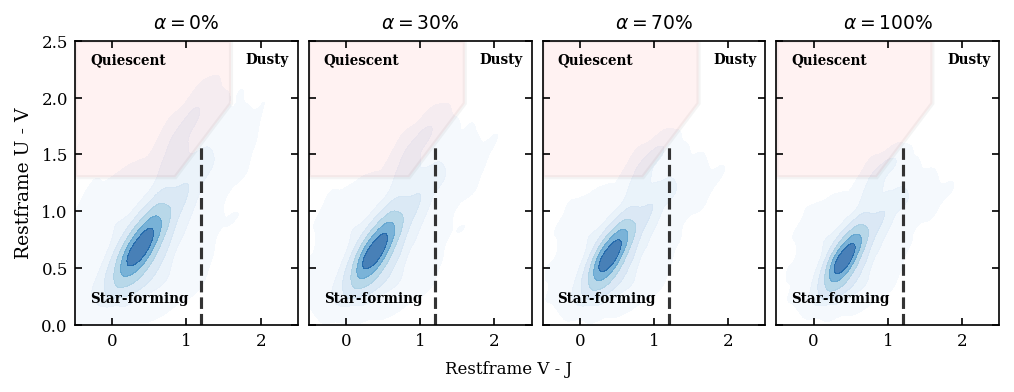

In [11]:
# --- Type 1 AGN UVJ Density Evolution (4-panel, ZFOURGE observational data) ---
alpha_cols   = [0, 30, 70, 100]
alpha_labels = [r'$\alpha=0\%$', r'$\alpha=30\%$', r'$\alpha=70\%$', r'$\alpha=100\%$']

fig, axes = plt.subplots(1, 4, figsize=(6.85, 2.5), sharex=True, sharey=True)

for ax, a, label in zip(axes, alpha_cols, alpha_labels):
    vj = df_obs[f'V_{a}'] - df_obs[f'J_{a}']
    uv = df_obs[f'U_{a}'] - df_obs[f'V_{a}']
    valid = vj.notna() & uv.notna()
    sns.kdeplot(x=vj[valid], y=uv[valid],
                fill=True, cmap='Blues', levels=7, thresh=0.02, alpha=0.75, ax=ax)
    visualization.plot_uvj_diagram([], [], ax=ax, title=label)
    for txt in ax.texts:
        txt.set_fontsize(6.5)
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].set_ylabel('Restframe U - V')
fig.text(0.5, -0.01, 'Restframe V - J', ha='center', fontsize=8)

plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_Type1_Density_Evolution.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## Export: Paper-Required Figures

Copies the subset of plots referenced by `Context/AGNPaper/paper.tex` into `outputs/PaperFigures/`, so that folder always reflects exactly what the paper needs (see `config.PAPER_FIGURE_MANIFEST`).

In [12]:
# Export the subset of plots required by Context/AGNPaper/paper.tex into
# outputs/PaperFigures/, and - if the gitignored Overleaf checkout is present
# locally - straight into its Images/TheoreticalModelPlots/ folder too, so
# the paper never silently references a stale/missing figure.
# (see config.PAPER_FIGURE_MANIFEST for the full list)
import shutil

os.makedirs(config.PAPER_FIGURES_DIR, exist_ok=True)
overleaf_present = os.path.isdir(config.AGNPAPER_DIR)
if overleaf_present:
    os.makedirs(config.PAPER_OVERLEAF_IMAGES_DIR, exist_ok=True)

copied, missing = [], []
for paper_filename, rel_source in config.PAPER_FIGURE_MANIFEST.items():
    src_path = os.path.join(config.PROCESSED_DATA_DIR, rel_source)
    dst_path = os.path.join(config.PAPER_FIGURES_DIR, paper_filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        if overleaf_present:
            shutil.copy2(src_path, os.path.join(config.PAPER_OVERLEAF_IMAGES_DIR, paper_filename))
        copied.append(paper_filename)
    else:
        missing.append(paper_filename)

print(f"Paper figures exported to {config.PAPER_FIGURES_DIR}")
if overleaf_present:
    print(f"  also copied to {config.PAPER_OVERLEAF_IMAGES_DIR}")
print(f"  {len(copied)}/{len(config.PAPER_FIGURE_MANIFEST)} copied")
if missing:
    print("  Still missing (not yet generated by any notebook run):")
    for name in missing:
        print(f"    - {name}")
    print("  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb")
    print("  (both top to bottom) to generate every required source plot.")
else:
    print("  All paper-required figures present.")

Paper figures exported to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\PaperFigures
  also copied to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\Context\AGNPaper\Images\TheoreticalModelPlots
  14/14 copied
  All paper-required figures present.
